In [1]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [21]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from sklearn.metrics.pairwise import cosine_similarity

from damo.config.base import parse_config
from tools.demo import Infer

from my_help_functions.hooks import register_conv_bn_hooks
from my_help_functions.cosine_matrix import get_positions_of_classes_on_flattened_image, get_positions_of_classes_on_flattened_image_for_collage


In [3]:
config = parse_config('./configs/damoyolo_tinynasL20_T.py')

infer_engine = Infer(config, device='cuda',
    ckpt='./weights/damoyolo_tiny.pth')

model = infer_engine.model.eval()

Inference with torch engine!


In [4]:
# for name, layer in list(model.named_modules()):
#     print(name, layer)

In [5]:
savefig = True

idx = 5
path = f'./collage/gray_collage_background_centroid_{idx}.jpg'

In [6]:
bns, convs = register_conv_bn_hooks(model)

In [7]:
origin_image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image, origin_shape = infer_engine.preprocess(origin_image)
output = model(image)

In [8]:
len(convs)

47

In [9]:
before_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])
after_conv = np.array([convs[i][2].detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.
c:\Users\asche

In [10]:
after_center = np.array([bns[i][2].detach().cpu() - bns[i][1].running_mean.view(-1, 1, 1).detach().cpu() for i in range(len(bns))])

c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
c:\Users\asche\anaconda3\envs\DAMO-YOLO\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


In [11]:
for i in range(len(after_conv)):
    print(before_conv[i].shape, after_conv[i].shape, after_center[i].shape)

torch.Size([12, 320, 320]) torch.Size([12, 320, 320]) torch.Size([24, 320, 320])
torch.Size([24, 320, 320]) torch.Size([24, 320, 320]) torch.Size([24, 320, 320])
torch.Size([64, 160, 160]) torch.Size([64, 160, 160]) torch.Size([24, 160, 160])
torch.Size([64, 160, 160]) torch.Size([64, 160, 160]) torch.Size([64, 160, 160])
torch.Size([96, 80, 80]) torch.Size([96, 80, 80]) torch.Size([64, 80, 80])
torch.Size([96, 80, 80]) torch.Size([96, 80, 80]) torch.Size([96, 80, 80])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([96, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([152, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([152, 40, 40])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.Size([192, 40, 40])
torch.Size([384, 20, 20]) torch.Size([384, 20, 20]) torch.Size([192, 20, 20])
torch.Size([768, 20, 20]) torch.Size([768, 20, 20]) torch.Size([384, 20, 20])
torch.Size([192, 40, 40]) torch.Size([192, 40, 40]) torch.S

In [44]:
from tabulate import tabulate

data = [(name, module, input.size(), output.size()) for name, module, input, output in convs]
print(tabulate(data, headers=["Название", "Слой", "Размер входа", "Размер выхода"], tablefmt="grid"))

+------------------------------------------------+---------------------------------------------------------------------------------+----------------------------+----------------------------+
| Название                                       | Слой                                                                            | Размер входа               | Размер выхода              |
+================================================+=================================================================================+============================+============================+
| backbone.block_list.0.conv.conv                | Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)   | torch.Size([12, 320, 320]) | torch.Size([24, 320, 320]) |
+------------------------------------------------+---------------------------------------------------------------------------------+----------------------------+----------------------------+
| backbone.block_list.1.block_list.0.conv1.co

In [12]:
import torch.nn.functional as F

def pairwise_cosine_similarity(x1, x2):
    x1 = F.normalize(x1, dim=0)
    x2 = F.normalize(x2, dim=0)
    return x1.T @ x2

In [13]:
inside = []
outside = []
back = []

# q = torch.Tensor([0.05, 0.25, 0.5, 0.75, 0.95])

for k in tqdm(range(2, len(after_center))):
# for k in range(2, 3):
    # positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_", "background_centroid_")
    positions, class_names = get_positions_of_classes_on_flattened_image_for_collage(idx, after_center[k].size()[1], "gray_")

    # if before_conv[k].size()[1] != after_conv[k].size()[1]:
    #     # a = after_conv[k].copy()
    #     u = torch.nn.Upsample(scale_factor=2, mode='bilinear')
    #     a = u(after_conv[k].unsqueeze(0)).squeeze()
    #     matr1 = a.flatten(1, 2).detach()
    # else:
    #     matr1 = after_conv[k].flatten(1, 2).detach()
    # matr2 = before_conv[k].flatten(1, 2).detach()
    matr = after_center[k].flatten(1, 2).detach()

    # csm = pairwise_cosine_similarity(matr1, matr1) - pairwise_cosine_similarity(matr2, matr2) # torch.tensor
    csm = pairwise_cosine_similarity(matr, matr) # torch.tensor
    n = len(positions)

    mean_angle_change_w_others_list = []
    angle_change_w_self_list = []
    angle_change_w_back_list = []

    for i in range(n - 1):
    # Для 1 класса
    # for i in range(1):

        mean_angle_change_w_others = 0
        angle_change_w_self = 0
        angle_change_w_back = 0
        # mean_angle_change_w_others_list_inner = []
        # angle_change_w_self_list_inner = []
        # angle_change_w_back_list_inner = []
        
        for j in range(n):
            pos_i = torch.tensor(positions[i + 1], device=csm.device)
            pos_j = torch.tensor(positions[j + 1], device=csm.device)
            pair_matrix = torch.meshgrid(pos_i, pos_j)
            submatrix = csm[pair_matrix[0], pair_matrix[1]]

            mean = submatrix.mean()
            # quantiles = torch.quantile(submatrix.flatten(), q)
            
            if i == j:
                angle_change_w_self_list.append(mean)
                # angle_change_w_self_list_inner.append(quantiles)
                angle_change_w_self = mean
            elif j == (n - 1):
                angle_change_w_back_list.append(mean)
                # angle_change_w_back_list_inner.append(quantiles)
                angle_change_w_back = mean
            else:
                mean_angle_change_w_others += mean
                # mean_angle_change_w_others_list_inner.append(quantiles)
        
        mean_angle_change_w_others /= (n - 2)
        mean_angle_change_w_others_list.append(mean_angle_change_w_others)
        # angle_change_w_self_list.append(torch.stack(angle_change_w_self_list_inner).mean(dim=0))
        # angle_change_w_back_list.append(torch.stack(angle_change_w_back_list_inner).mean(dim=0))
        # mean_angle_change_w_others_list.append(torch.stack(mean_angle_change_w_others_list_inner).mean(dim=0))

    inside.append(torch.tensor(angle_change_w_self_list).mean())
    outside.append(torch.tensor(mean_angle_change_w_others_list).mean())
    back.append(torch.tensor(angle_change_w_back_list).mean())
    
    # inside.append(torch.stack(angle_change_w_self_list).mean(dim=0))
    # outside.append(torch.stack(mean_angle_change_w_others_list).mean(dim=0))
    # back.append(torch.stack(angle_change_w_back_list).mean(dim=0))


  0%|          | 0/45 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=2.88s)
creating index...
index created!
loading annotations into memory...
Done (t=3.39s)
creating index...
index created!
loading annotations into memory...
Done (t=2.36s)
creating index...
index created!
loading annotations into memory...
Done (t=1.57s)
creating index...
index created!
loading annotations into memory...
Done (t=1.50s)
creating index...
index created!
loading annotations into memory...
Done (t=1.34s)
creating index...
index created!
loading annotations into memory...
Done (t=1.06s)
creating index...
index created!
loading annotations into memory...
Done (t=1.67s)
creating index...
index created!
loading annotations into memory...
Done (t=1.73s)
creating index...
index created!
loading annotations into memory...
Done (t=1.71s)
creating index...
index created!
loading annotations into memory...
Done (t=1.49s)
creating index...
index created!
loading annotations into memory...
Done (t=1.29s)
creating index...
index created!
load

In [14]:
# inside, outside, back

In [16]:
def scale(X, mini, maxi, range_=(-1, 1)):
    min_, max_ = range_
    X = np.array(X)
    X_std = (X - mini) / (maxi - mini)
    X_scaled = X_std * (max_ - min_) + min_
    return X_scaled

# a_min = min(np.min(inside), np.min(outside), np.min(back))
# a_max = max(np.max(inside), np.max(outside), np.max(back))
# inside_scaled = scale(inside, a_min, a_max)
# outside_scaled = scale(outside, a_min, a_max)
# back_scaled = scale(back, a_min, a_max)


In [16]:
inside_np = torch.stack(inside).cpu().numpy()  # (95, 5)
outside_np = torch.stack(outside).cpu().numpy()  # (95, 5)
back_np = torch.stack(back).cpu().numpy()  # (95, 5)

In [18]:
bns_fwd_names = [name for name, _, _, _ in bns]
len(bns_fwd_names)

47

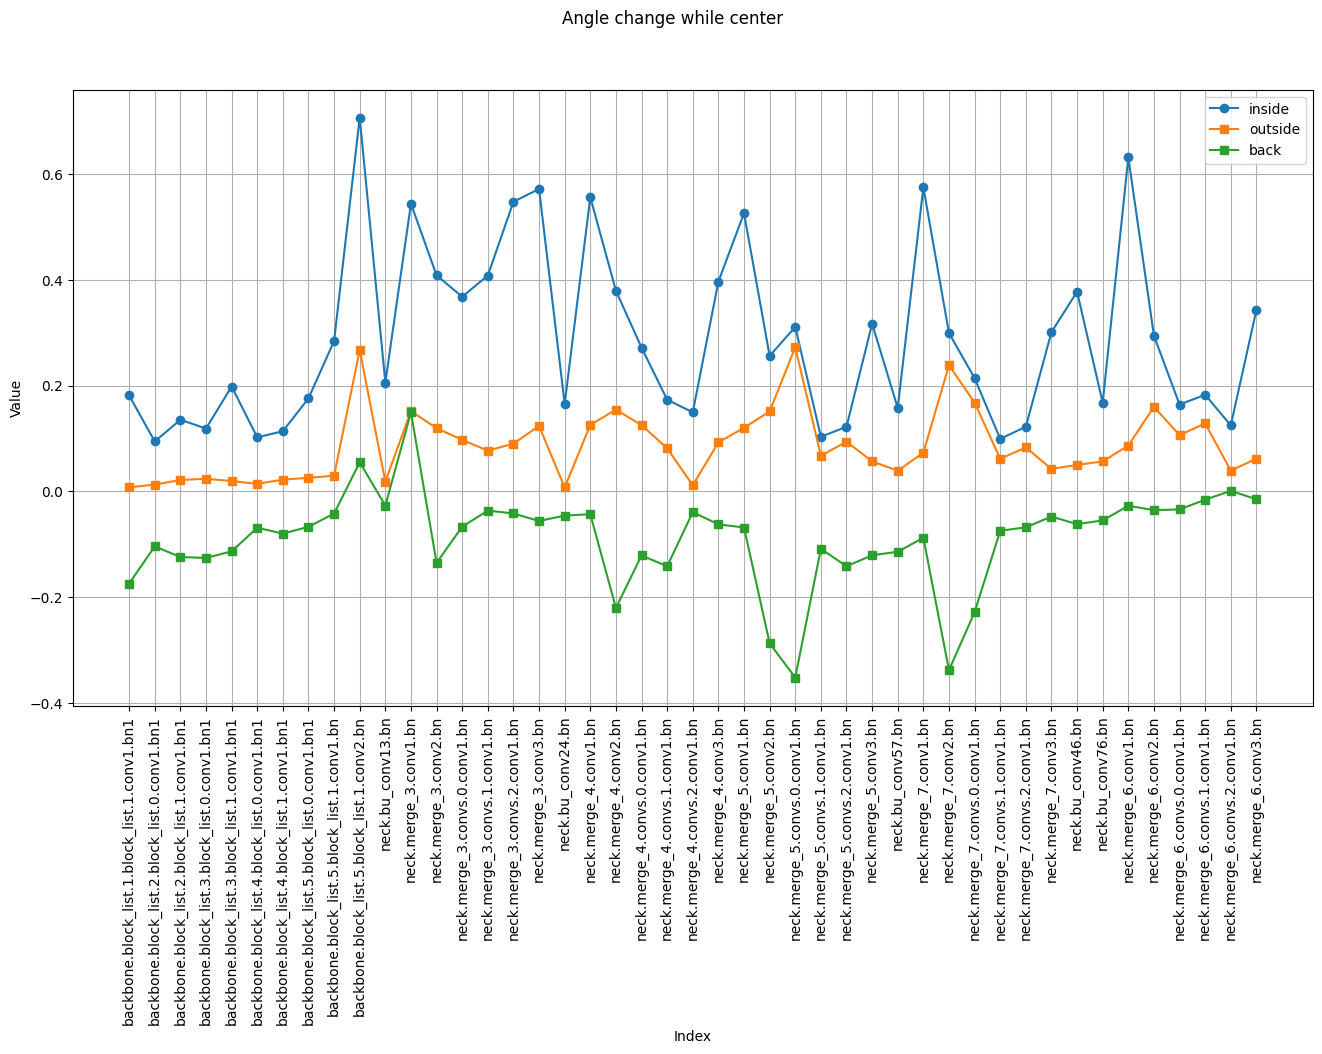

In [34]:
x = np.arange(3, len(before_conv) + 1)

plt.figure(figsize=(16, 8))

# _np[:, 2]
plt.plot(x, inside, marker='o', label='inside', linestyle='-')
plt.plot(x, outside,  marker='s', label='outside', linestyle='-')
plt.plot(x, back,  marker='s', label='back', linestyle='-')

# plt.xticks(x, [str(i) for i in x], rotation=90)
plt.xticks(x, [bns_fwd_names[i - 1] for i in x], rotation=90)

# plt.axvline(x=30.5, color='black', linestyle='--')

# plt.text(10, 0.8, 'Backbone', ha='right', fontsize=12)
# plt.text(40, 0.8, 'Neck', ha='left', fontsize=12)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center")
# if savefig: plt.savefig("18.10. Изменение углов по всей модели при свёртке.png")
plt.show();


In [23]:
import re
from collections import defaultdict, deque

def clean_label(label):
    # # Удаляем всё после скобок (если есть)
    # label = re.sub(r'\s*\(.*?\)', '', label)
    # return label.strip()
    return label.split()[0].strip('"')

def parse_graphviz_file(file_path):
    edges = []  # Список ребер (id_from, id_to)
    labels = {}  # id -> label

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            edge_match = re.match(r'(\d+)\s*->\s*(\d+)', line)
            if edge_match:
                src, dst = edge_match.groups()
                edges.append((src, dst))
                continue

            label_match = re.match(r'(\d+)\s*\[label=(.+?)\]', line)
            if label_match:
                node_id, raw_label = label_match.groups()
                clean = clean_label(raw_label)
                labels[node_id] = clean

    return edges, labels

def build_graph(edges):
    forward = defaultdict(list)
    backward = defaultdict(list)
    for src, dst in edges:
        forward[src].append(dst)
        backward[dst].append(src)
    return forward, backward

def find_batchnorm_names(forward, backward, labels):
    batchnorm_map = {}

    for node_id, label in labels.items():
        if label != 'NativeBatchNormBackward0':
            continue

        # Ищем соседей назад (в AccumulateGrad)
        acc_nodes = backward.get(node_id, [])
        for acc in acc_nodes:
            if labels.get(acc) != 'AccumulateGrad':
                continue

            # Назад от AccumulateGrad, ищем узел с названием
            for candidate in backward.get(acc, []):
                name = labels.get(candidate)
                if name and 'bn' in name:
                    batchnorm_map[node_id] = '.'.join(name.split('.')[:-1])
                    break

            if node_id in batchnorm_map:
                break  # Достаточно одного имени

    return batchnorm_map

def bfs_batchnorm_connections(start_nodes, forward, labels, batchnorm_map):
    result = defaultdict(list)
    id_to_name = {v: k for k, v in batchnorm_map.items()}

    for src_id, src_name in batchnorm_map.items():
        visited = set()
        queue = deque([src_id])

        while queue:
            current = queue.popleft()
            for neighbor in forward.get(current, []):
                if neighbor in visited:
                    continue
                visited.add(neighbor)

                if neighbor in batchnorm_map and neighbor != src_id:
                    result[src_name].append(batchnorm_map[neighbor])
                else:
                    queue.append(neighbor)

    return result

# --- Пример использования ---
file_path = './architecture.txt'
edges, labels = parse_graphviz_file(file_path)
forward, backward = build_graph(edges)
batchnorm_map = find_batchnorm_names(forward, backward, labels)
connections = bfs_batchnorm_connections(batchnorm_map, forward, labels, batchnorm_map)
connections['neck.merge_6.conv3.bn'] = []

for bn_label, reachable_bn_labels in connections.items():
    print(f"{bn_label} -> {reachable_bn_labels}")


neck.merge_5.conv3.bn -> ['neck.bu_conv57.bn']
neck.merge_5.conv1.bn -> ['neck.merge_5.conv3.bn']
backbone.block_list.2.block_list.1.conv1.bn1 -> ['backbone.block_list.3.block_list.0.conv1.bn1', 'neck.bu_conv24.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
backbone.block_list.2.block_list.0.conv1.bn1 -> ['backbone.block_list.2.block_list.1.conv1.bn1', 'backbone.block_list.3.block_list.0.conv1.bn1', 'neck.bu_conv24.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
backbone.block_list.1.block_list.1.conv1.bn1 -> ['backbone.block_list.2.block_list.0.conv1.bn1']
backbone.block_list.1.block_list.0.conv1.bn1 -> ['backbone.block_list.1.block_list.1.conv1.bn1', 'backbone.block_list.2.block_list.0.conv1.bn1']
backbone.block_list.0.conv.bn -> ['backbone.block_list.1.block_list.0.conv1.bn1']
neck.merge_4.conv3.bn -> ['neck.bu_conv46.bn', 'neck.merge_7.conv1.bn', 'neck.merge_7.conv2.bn', 'neck.merge_5.conv1.bn', 'neck.merge_5.conv2.bn']
neck.merge_4.conv1.bn -> ['neck.merge_4.conv3.b

In [82]:
def draw_bn_dependency_graph_inline(ax, y_values, bns_fwd_names, bn_connections):
    x_coords = {name: i for i, name in enumerate(bns_fwd_names)}
    y_min = min(y_values)
    base_y = y_min - 0.5

    allowed = set(bns_fwd_names)
    edges = [
        (src, dst) for src, dsts in bn_connections.items() if src in allowed
        for dst in dsts if dst in allowed
    ]
    pos = {name: (x_coords[name], base_y) for name in bns_fwd_names}

    for src, dst in edges:
        x1, y1 = pos[src]
        x2, y2 = pos[dst]
        dx = abs(x2 - x1)

        if dx == 1:
            style = "arc3,rad=0.01"
            width = 0.5
            color = "gray"
        else:
            style = f"arc3,rad={0.3 if dx < 5 else 0.5}"
            width = 1.0
            color = "darkblue"

        ax.annotate(
            "", xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>", lw=width, color=color, connectionstyle=style)
        )

    highlight_nodes = {
        "neck.merge_7.conv3.bn",
        "neck.merge_6.conv3.bn",
        "neck.merge_5.conv3.bn",
    }

    for name, (x, y) in pos.items():
        from matplotlib.patches import Ellipse
        ax.plot(x, y, 'o', color='black', markersize=4)
        # ax.text(x, y - 0.2, name, fontsize=7, rotation=90, ha='center', va='top')

        if name in highlight_nodes:
            # Добавляем обводку вокруг узла
            ax.add_patch(Ellipse((x, y), 0.7, 0.07, fill=False, color='red'))

    ax.set_ylim(base_y - 0.5, max(y_values) + 0.5)


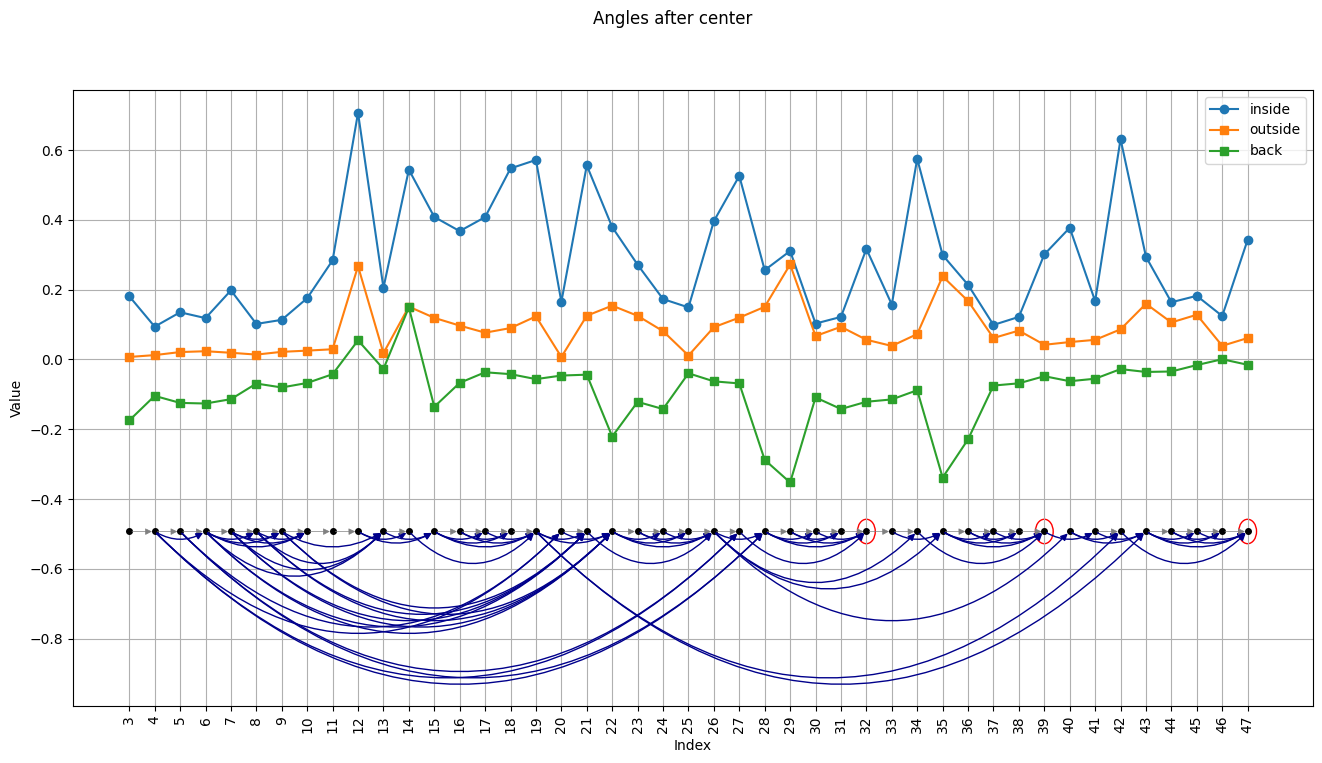

In [83]:
# x = np.arange(3, len(before_conv) + 1)
x = np.arange(0, len(before_conv) - 2)

# plt.figure(figsize=(16, 8))
fig, ax = plt.subplots(figsize=(16, 8))

# _np[:, 2]
ax.plot(x, inside, marker='o', label='inside', linestyle='-')
ax.plot(x, outside,  marker='s', label='outside', linestyle='-')
ax.plot(x, back,  marker='s', label='back', linestyle='-')

draw_bn_dependency_graph_inline(ax, outside, bns_fwd_names[2:], connections)
# plt.tight_layout()
# plt.show()
plt.xticks(x, [str(i + 3) for i in x], rotation=90)
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angles after center")
# if savefig: plt.savefig("18.10. Изменение углов по всей модели при свёртке.png")
plt.show();

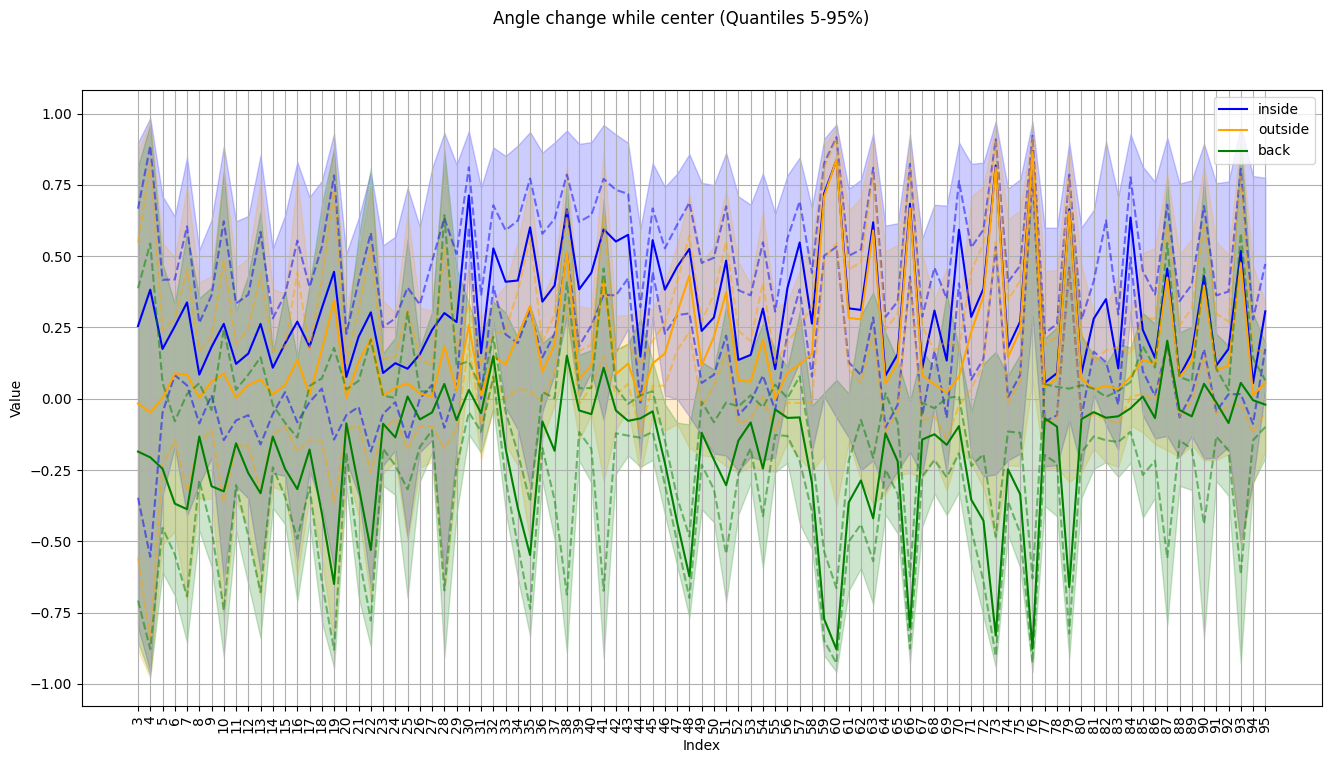

In [67]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(3, len(before_conv) + 1)

# inside = torch.stack(inside).cpu().numpy()  # (95, 5)
# outside = torch.stack(outside).cpu().numpy()
# back = torch.stack(back).cpu().numpy()

plt.figure(figsize=(16, 8))

# Функция для отрисовки трубки + линий
def plot_with_quantiles(x, quantiles, label, color):
    q05 = quantiles[:, 0]
    q25 = quantiles[:, 1]
    q50 = quantiles[:, 2]
    q75 = quantiles[:, 3]
    q95 = quantiles[:, 4]
    
    # Трубка между 5% и 95%
    plt.fill_between(x, q05, q95, alpha=0.2, color=color)
    
    # Дополнительно 25%-75%
    plt.plot(x, q25, linestyle='--', color=color, alpha=0.5)
    plt.plot(x, q75, linestyle='--', color=color, alpha=0.5)

    # Основная линия медианы
    plt.plot(x, q50, label=label, color=color)

# Рисуем все 3 серии
plot_with_quantiles(x, inside_np, label='inside', color='blue')
plot_with_quantiles(x, outside_np, label='outside', color='orange')
plot_with_quantiles(x, back_np, label='back', color='green')

plt.xticks(x, [str(i) for i in x], rotation=90)

plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.suptitle("Angle change while center (Quantiles 5-95%)")
plt.show()
